## PARROTS WORKSHOP ##

## Step 7. Setup check

In [1]:
from pathlib import Path
import yaml
import sys

# Find workshop folder
WORKSHOP_DIR = Path.cwd().resolve()
if WORKSHOP_DIR.name == "notebooks":
    WORKSHOP_DIR = WORKSHOP_DIR.parent

EXAMPLE_DIR = WORKSHOP_DIR / "Example"

# Load main config
CONFIG_PATH = EXAMPLE_DIR / "config.yaml"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# Helper: make relative paths start from Example/
def fix_path(p):
    p = Path(p).expanduser()
    return p if p.is_absolute() else EXAMPLE_DIR / p

# Load environment config
ENV_CONFIG_PATH = fix_path(config["environment"]).resolve()

with open(ENV_CONFIG_PATH) as f:
    env_file = yaml.safe_load(f)

env_config = env_file["environment"]

# Read paths
PARROTS_DIR = Path(env_config["parrots_dir"]).expanduser().resolve()
BASE_DIR = fix_path(config["input_options"]["base_dir"]).resolve()
INPUT_PDB = fix_path(config["input_options"]["input_pdb"]).resolve()
TEMPLATE_FASTA = fix_path(config["input_options"]["template_fasta"]).resolve()
BINDER_CHAIN = config["input_options"]["binder_chain"]

# Print paths
print("Workshop directory:", WORKSHOP_DIR)
print("Example directory:", EXAMPLE_DIR)
print("Config path:", CONFIG_PATH)
print("Environment config:", ENV_CONFIG_PATH)
print("PARROTS directory:", PARROTS_DIR)
print("Base directory:", BASE_DIR)
print("Input PDB:", INPUT_PDB)
print("Template FASTA:", TEMPLATE_FASTA)
print("Binder chain:", BINDER_CHAIN)

# Check paths
assert CONFIG_PATH.exists(), "Config file not found"
assert ENV_CONFIG_PATH.exists(), "Environment config file not found"
assert PARROTS_DIR.exists(), "PARROTS directory not found"
assert BASE_DIR.exists(), "base_dir not found"
assert INPUT_PDB.exists(), "input_pdb not found"
assert TEMPLATE_FASTA.exists(), "template_fasta not found"

print("\nSetup check passed.")

Workshop directory: /ifs/scratch2/home/bs3281/PARROTS_workshop
Example directory: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example
Config path: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/config.yaml
Environment config: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/environment.yaml
PARROTS directory: /ifs/scratch2/home/bs3281/PARROTS
Base directory: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example
Input PDB: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/inputs/PD1_PDBs/4zqk_PD1_rx.pdb
Template FASTA: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/inputs/4ZQK_pd1_truncated.fasta
Binder chain: A

Setup check passed.


# ITER_1 Design: analysis

In [ ]:
Design_output_dir = "/ifs/scratch2/home/bs3281/PARROTS_workshop/TEST_BS/ITER_1/Design_output"

In [ ]:
import sys
sys.path.insert(0, str(PARROTS_DIR))

from PARROTS_Analysis.parrots_plots import calculate_design_pass_rates

percent_pass = calculate_design_pass_rates(Design_output_dir)

[step_1] 8/10 passed (80.00%)
[step_2] 6/16 passed (37.50%)


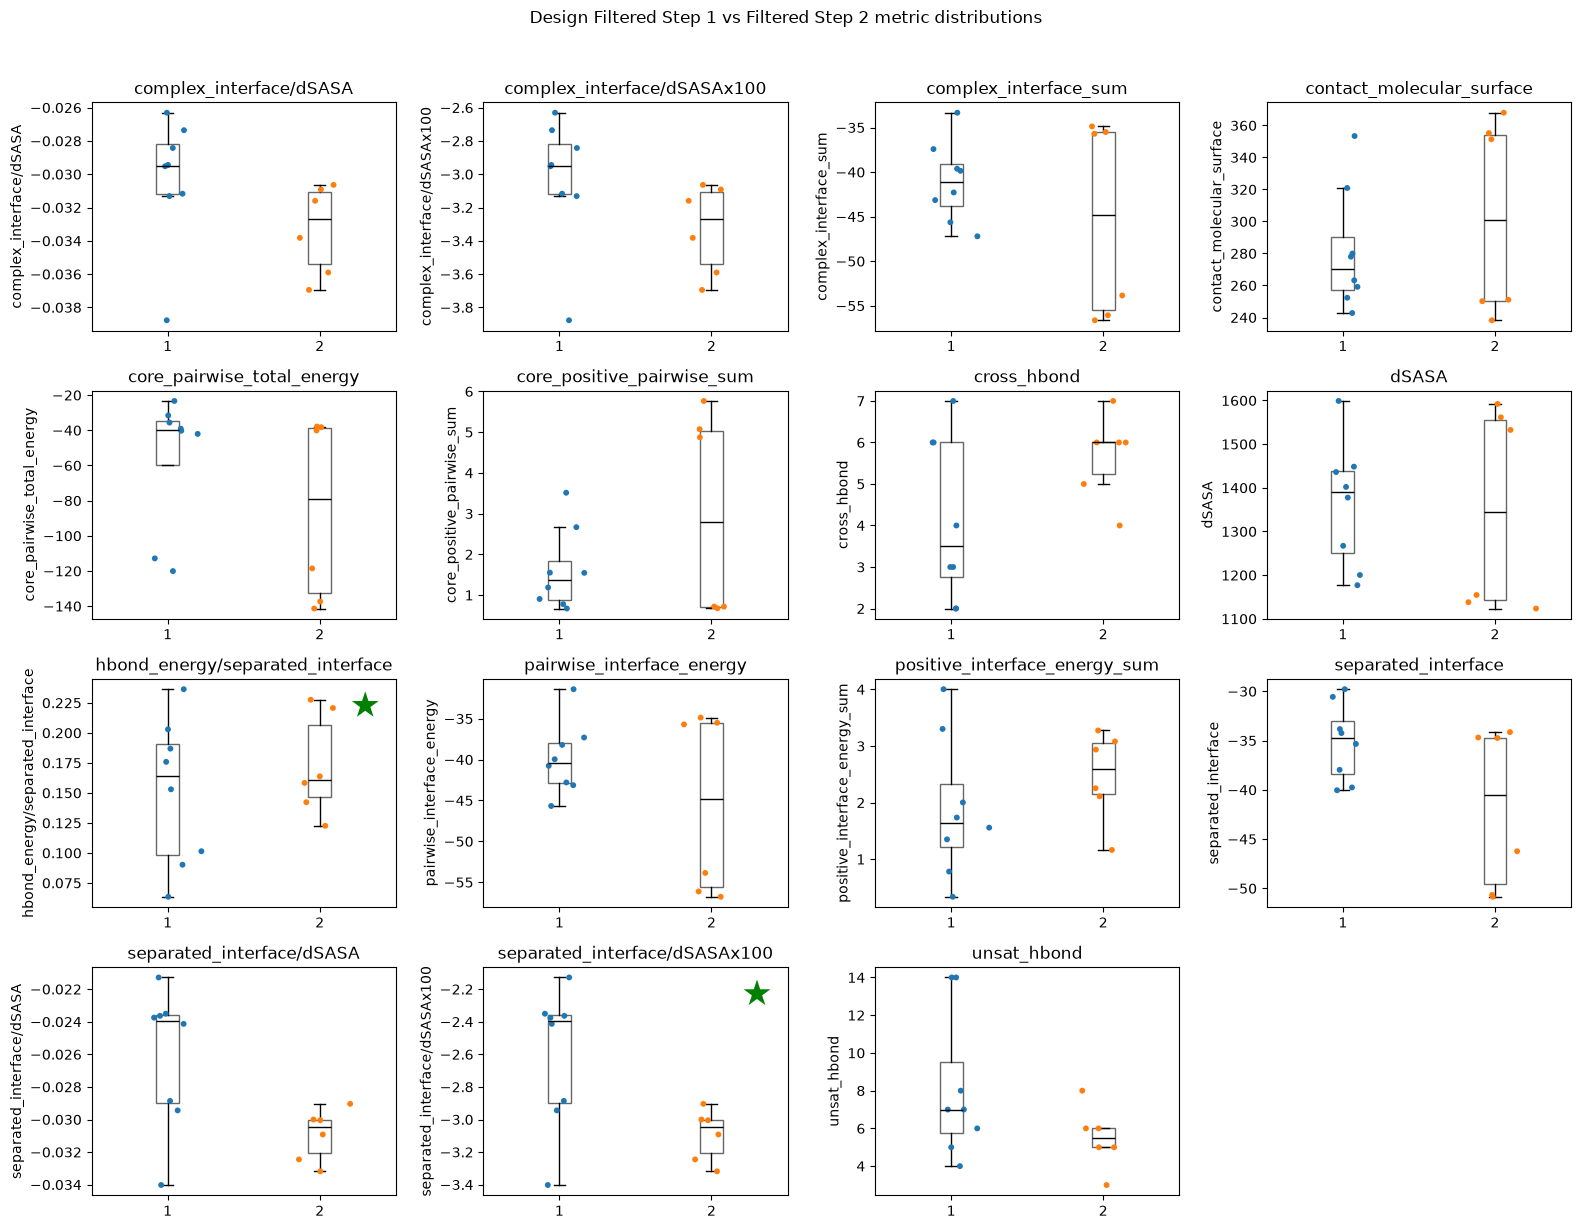

In [ ]:
from PARROTS_Analysis.parrots_plots import plot_step1_vs_step2_metric_boxplots

fig, axes = plot_step1_vs_step2_metric_boxplots(Design_output_dir)

In [ ]:
import sys

PARROTS_ROOT = Path(parrots_dir_path)

possible_paths = [
	PARROTS_ROOT,
	PARROTS_ROOT / "Design",
	PARROTS_ROOT / "Predict_Structure",
	PARROTS_ROOT / "RFDiffusion",
]

for p in possible_paths:
	if p.exists():
		sys.path.append(str(p))

# from Utilities import utilities
from Design.Utilities import utilities

NameError: name 'parrots_dir_path' is not defined

In [ ]:
import pandas as pd
import Bio
import yaml
import torch

print("Environment is working")

Environment is working


Run the RFD scaffold generation step: 

bash <PARROTS/run_parrots_pipeline.sh> <PARROTS/configs/master_config.yaml>

In [ ]:
# import py3Dmol
# from pathlib import Path

# pdb_path = Path("/path/to/your/model.pdb")

# with open(pdb_path) as f:
#     pdb_data = f.read()

# view = py3Dmol.view(width=800, height=600)
# view.addModel(pdb_data, "pdb")

# view.setStyle({"chain": "A"}, {"cartoon": {"color": "blue"}})   # binder
# view.setStyle({"chain": "B"}, {"cartoon": {"color": "gray"}})   # target

# view.zoomTo()
# view.show()

In [ ]:
import pyrosetta
pyrosetta.init()


┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.conda.ubuntu-20.04.cxx11thread.serialization.Ubuntu.python314.Release 2026.25+release.99f2f5edd2b52003f0e9f0a4a24a18254b3f4a0d 2026-06-07T17:04:44] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.conda.ubuntu-2

: 

In [ ]:
working_pose = pyrosetta.pose_from_pdb("/ifs/scratch2/home/bs3281/Computational_Workshop_PARROTS/PD1_PDBs/relax_renum/4zqk_4z18_PD1_PDL1_rx.pdb")

interface_analyzer = pyrosetta.rosetta.protocols.analysis.InterfaceAnalyzerMover()
interface_analyzer.set_interface('A_B')
interface_analyzer.set_pack_separated(True)
interface_analyzer.apply(working_pose)
all_data = interface_analyzer.get_all_data()

face_A_list, face_B_list = utilities.metrics_rosetta.get_interface_residues(
	all_data,
)

core.chemical.GlobalResidueTypeSet: Finished initializing fa_standard residue type set.  Created 985 residue types
core.chemical.GlobalResidueTypeSet: Total time to initialize 0.525755 seconds.
core.import_pose.import_pose: File '/ifs/scratch2/home/bs3281/Computational_Workshop_PARROTS/PD1_PDBs/relax_renum/4zqk_4z18_PD1_PDL1_rx.pdb' automatically determined to be of type PDB from contents.
core.conformation.Conformation: Found disulfide between residues 22 96
core.conformation.Conformation: Found disulfide between residues 137 191
core.conformation.Conformation: Found disulfide between residues 234 295
core.conformation.Conformation: Found disulfide between residues 341 415
core.conformation.Conformation: Found disulfide between residues 456 510
protocols.analysis.InterfaceAnalyzerMover: Repacking separated Pose before running calculations
protocols.analysis.InterfaceAnalyzerMover: Using explicit constructor
protocols.analysis.InterfaceAnalyzerMover: Using interface constructor
protoco

In [9]:
import pyrosetta
import sys

PARROTS_DIR = '/ifs/scratch2/home/bs3281/PARROTS'
sys.path.insert(0, str(PARROTS_DIR))


from Predict_structure.Utilities import metrics_utils

pyrosetta.init()

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.conda.ubuntu-20.04.cxx11thread.serialization.Ubuntu.python314.Release 2026.25+release.99f2f5edd2b52003f0e9f0a4a24a18254b3f4a0d 2026-06-07T17:04:44] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.conda.ubuntu-2

In [11]:
import tempfile
import os

def load_cif_to_pose(cif_file_path):
	"""
	Patch CIF file (missing citation.title) and load it into PyRosetta
	by writing a temporary fixed CIF, then reading that.
	"""
	print(f"Loading .cif to pose: {cif_file_path}")
	# Read original CIF
	with open(cif_file_path, "r") as f:
		lines = f.readlines()

	# Append the missing CIF field Rosetta requires
	# lines.append('_citation.title  ""\n')

	# Create a safe temporary CIF file
	with tempfile.NamedTemporaryFile(delete=False, suffix=".cif") as tmp:
		tempcif = tmp.name
		tmp.write("".join(lines).encode())

	# Try to load with PyRosetta
	try:
		pose = pyrosetta.rosetta.core.import_pose.pose_from_file(
			tempcif,
			read_fold_tree=True,
			type=pyrosetta.rosetta.core.import_pose.FileType.CIF_file
		)
	finally:
		# Always clean up the temporary file
		if os.path.exists(tempcif):
			os.remove(tempcif)

	return pose

pose = load_cif_to_pose("/ifs/scratch2/home/bs3281/PARROTS_workshop/Test_2/ITER_1/Predict_output/AF3_output/4zqk_PD1_rx_4_2_model_1_model/seed-1_sample-0/4zqk_PD1_rx_4_2_model_1_model_seed-1_sample-0_model.cif")

Loading .cif to pose: /ifs/scratch2/home/bs3281/PARROTS_workshop/Test_2/ITER_1/Predict_output/AF3_output/4zqk_PD1_rx_4_2_model_1_model/seed-1_sample-0/4zqk_PD1_rx_4_2_model_1_model_seed-1_sample-0_model.cif
core.conformation.Conformation: Found disulfide between residues 137 198
